# Show grader terrains

This notebook loads a grader YAML file with `sIArena.grading`, creates all terrain cases, and plots them in 2D.

If a `.yaml` filename is passed as a notebook argument, it will be used. Otherwise it falls back to `resources/graders/IA_practica_0.yaml`.


In [1]:
CONFIGURATION_FILE = "IA_practica_3.yaml"

In [2]:
import sys
from pathlib import Path

try:
    import sIArena
except ModuleNotFoundError:
    source_path = None
    for candidate in (Path("../src"), Path("src")):
        resolved_candidate = candidate.resolve()
        if resolved_candidate.exists():
            source_path = resolved_candidate
            break
    if source_path is None:
        raise ModuleNotFoundError(
            "Could not import sIArena and no local src path was found."
        )
    sys.path.insert(0, str(source_path))
    import sIArena

from sIArena.grading import build_terrain_cases, load_grader_config


def resolve_grader_path(argv):
    for argument in argv[1:]:
        if argument.endswith((".yaml", ".yml")):
            candidate = Path(argument)
            if candidate.exists():
                return candidate
            for prefixed_candidate in (
                Path("resources/graders") / argument,
                Path("graders") / argument,
            ):
                if prefixed_candidate.exists():
                    return prefixed_candidate
            return candidate
    for candidate in (
        Path(f"resources/graders/{CONFIGURATION_FILE}"),
        Path(f"graders/{CONFIGURATION_FILE}"),
    ):
        if candidate.exists():
            return candidate
    return Path(f"resources/graders/{CONFIGURATION_FILE}")


grader_path = resolve_grader_path(sys.argv)
config = load_grader_config(grader_path)
terrain_cases = build_terrain_cases(config)

print(f"Grader file: {grader_path}")
print(f"Assignment: {config.assignment.id}")
print(f"Tests: {len(config.tests)}")
print(f"Terrain cases: {len(terrain_cases)}")


Grader file: graders/IA_practica_3.yaml
Assignment: IA_practica_3
Tests: 5
Terrain cases: 19


In [3]:
for terrain_case in terrain_cases:
    print(terrain_case.label)


dodge[seed=43]
dodge[seed=44]
dodge[seed=45]
dodge[seed=46]
dodge[seed=47]
walk[seed=43]
walk[seed=44]
walk[seed=45]
walk[seed=46]
walk[seed=47]
fields[seed=43]
fields[seed=44]
fields[seed=45]
fields[seed=46]
ocean[seed=43]
ocean[seed=44]
ocean[seed=45]
rafting[seed=43]
rafting[seed=44]


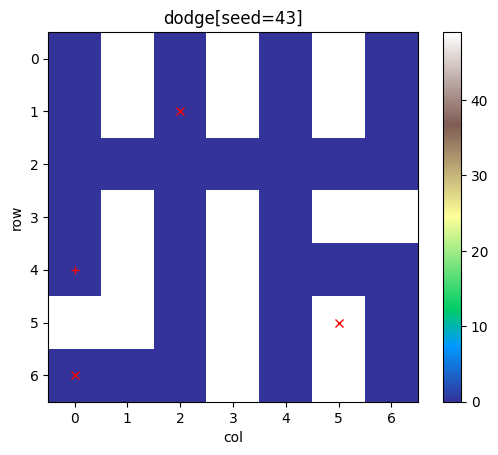

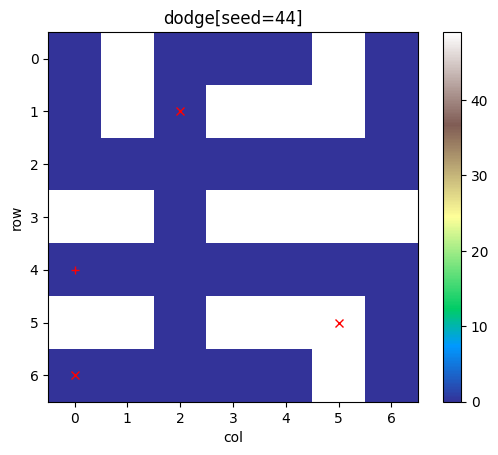

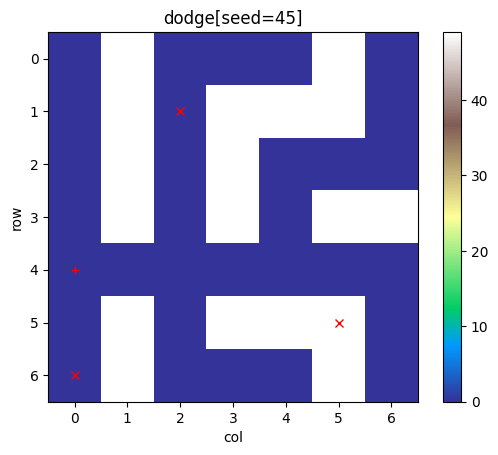

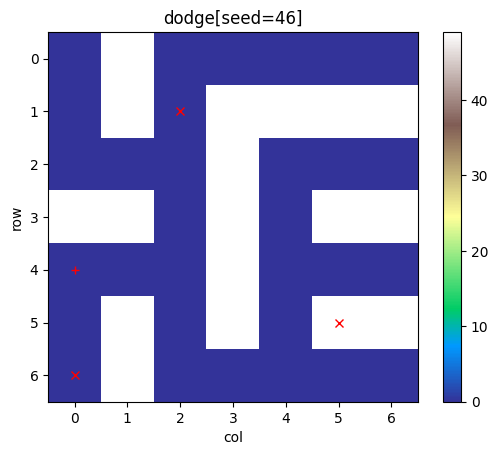

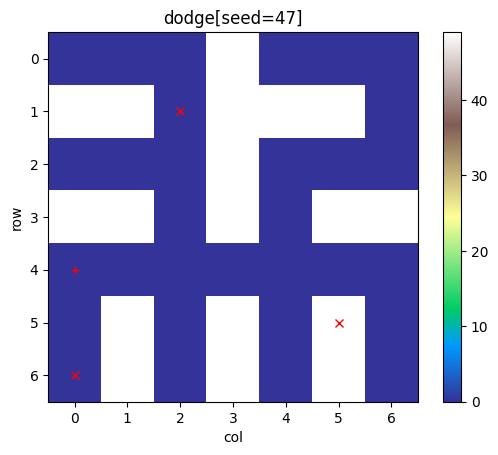

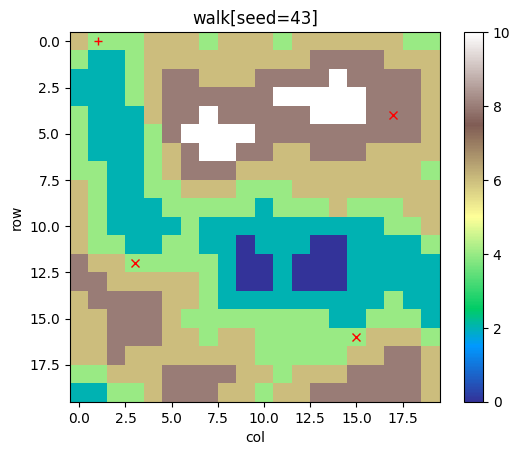

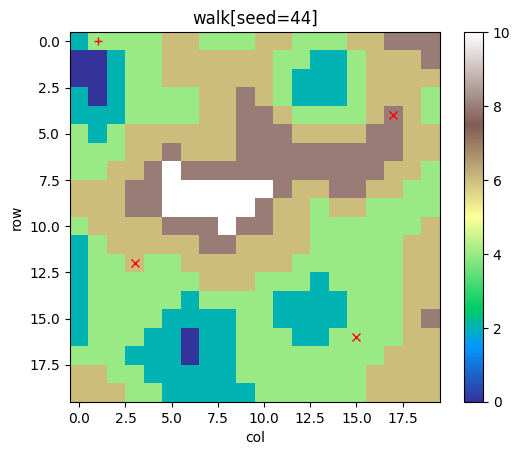

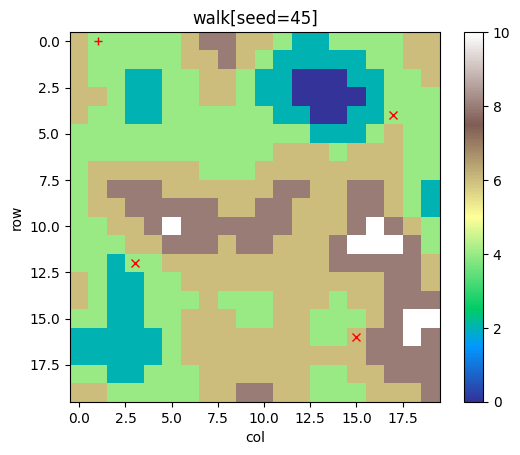

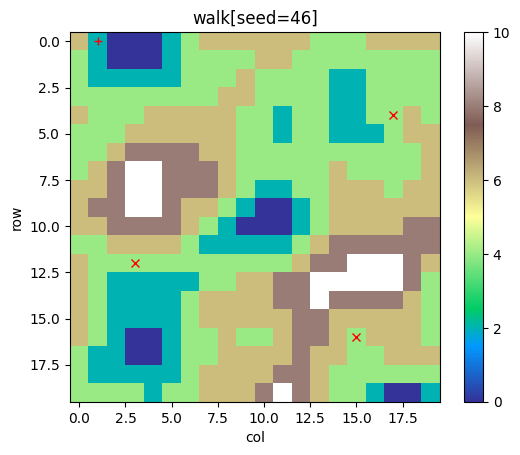

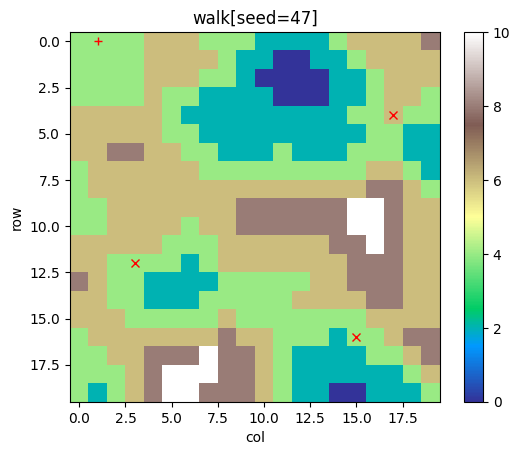

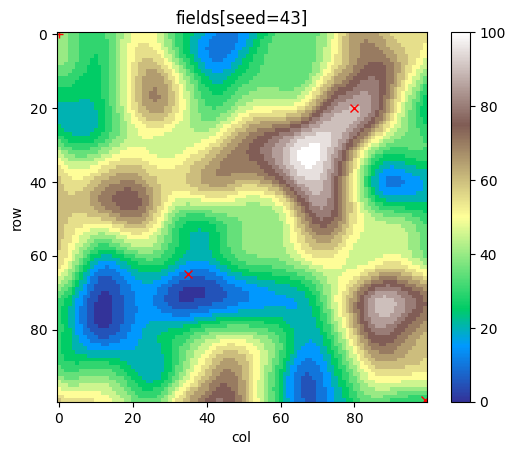

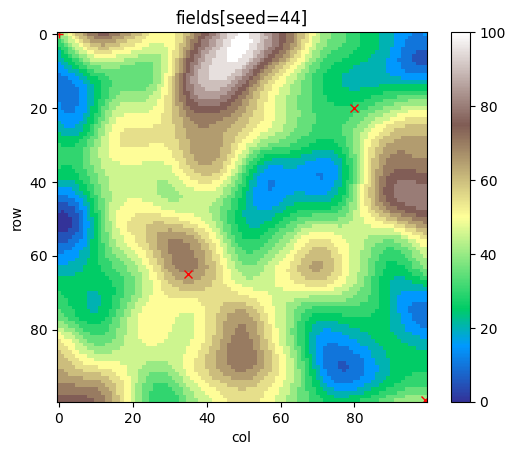

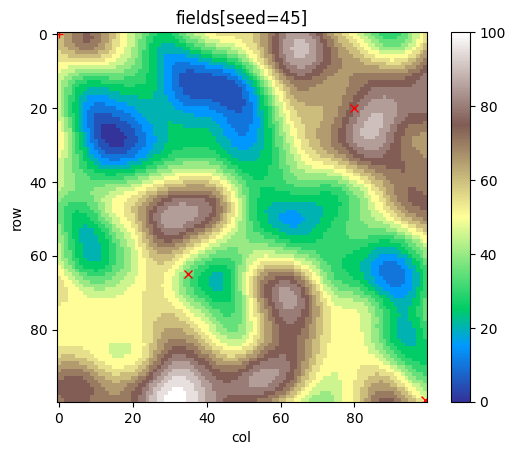

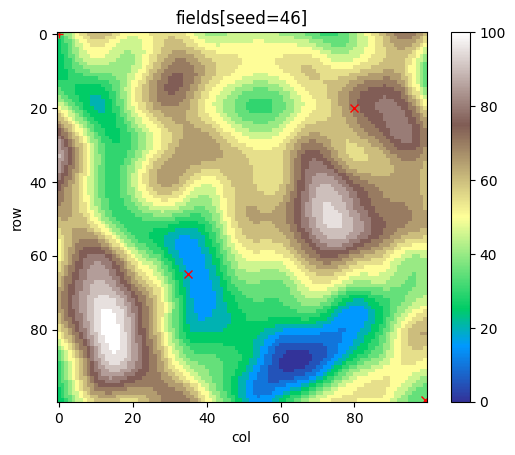

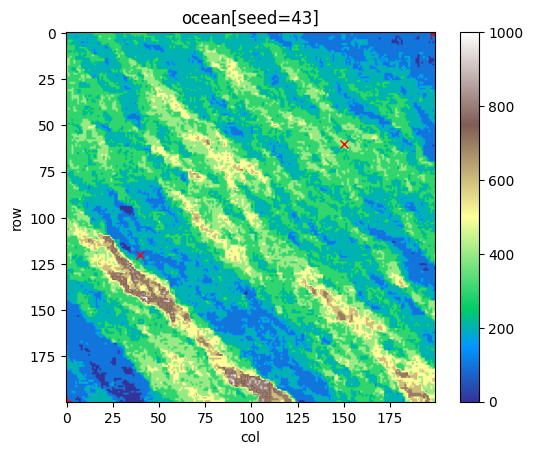

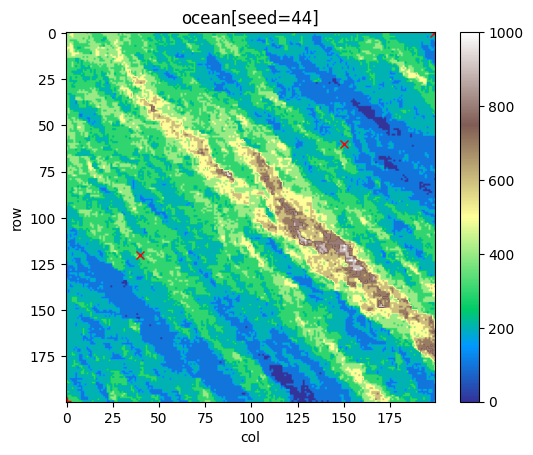

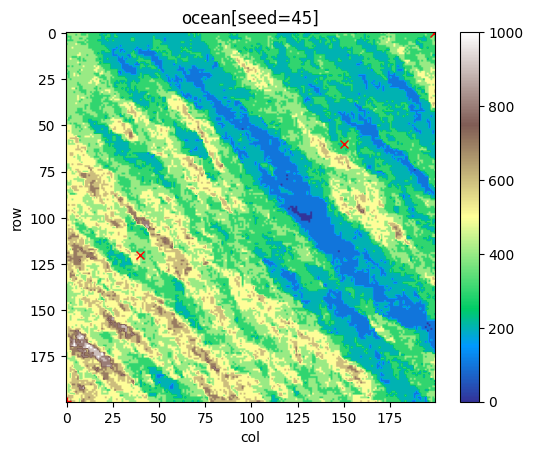

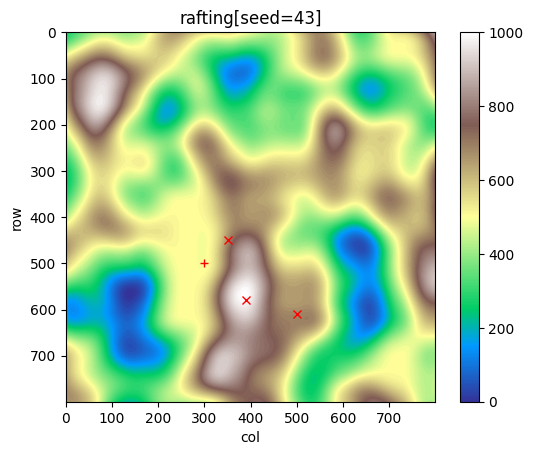

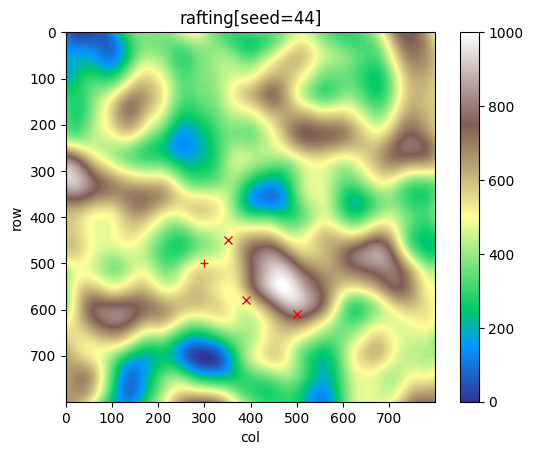

In [4]:
from sIArena.terrain.plot.plot_2D import plot_terrain_2D

for terrain_case in terrain_cases:
    plot_terrain_2D(terrain_case.terrain, title=terrain_case.label)
